In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [3]:
import os


In [4]:
def list_directories(path):
    """Lists all directories in the given path."""
    directories = []
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            directories.append(item)
    return directories
path = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

In [5]:
# Example usage:
print(f"Directories in '{path}':")
dirs_in_color_path = list_directories(path)
for d in dirs_in_color_path:
    print(d)

Directories in '/kaggle/input/plantvillage-dataset/plantvillage dataset/color':
Tomato___Late_blight
Tomato___healthy
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Soybean___healthy
Squash___Powdery_mildew
Potato___healthy
Corn_(maize)___Northern_Leaf_Blight
Tomato___Early_blight
Tomato___Septoria_leaf_spot
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Strawberry___Leaf_scorch
Peach___healthy
Apple___Apple_scab
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Bacterial_spot
Apple___Black_rot
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Peach___Bacterial_spot
Apple___Cedar_apple_rust
Tomato___Target_Spot
Pepper,_bell___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Potato___Late_blight
Tomato___Tomato_mosaic_virus
Strawberry___healthy
Apple___healthy
Grape___Black_rot
Potato___Early_blight
Cherry_(including_sour)___healthy
Corn_(maize)___Common_rust_
Grape___Esca_(Black_Measles)
Raspberry___healthy
Tomato___Leaf_Mold
Tomato___Spider_mites Two-spotted_s

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    batch_size=8,
    image_size=(224, 224),
    seed=42,
    subset="training",
    validation_split=0.25
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    batch_size=8,
    image_size=(224, 224),
    seed=42,
    subset="validation",
    validation_split=0.25
)
total = tf.data.experimental.cardinality(train_dataset).numpy()
train_size  = int(0.75 * total)

Found 54305 files belonging to 38 classes.
Using 40729 files for training.
Found 54305 files belonging to 38 classes.
Using 13576 files for validation.


In [7]:
class_names = train_dataset.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
# train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
# test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

In [8]:
for image, label in train_dataset.take(1):
    print("Image shape: ", image[0].shape)
    print("Label: ", label[0])


Image shape:  (224, 224, 3)
Label:  tf.Tensor(24, shape=(), dtype=int32)


In [9]:
y = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
class_weights_dict = dict(enumerate(class_weights))

In [10]:
print(class_weights_dict)

{0: np.float64(2.261214745725072), 1: np.float64(2.3712738705170007), 2: np.float64(5.103884711779449), 3: np.float64(0.8699803485987696), 4: np.float64(0.9451638355147127), 5: np.float64(1.3883624215980366), 6: np.float64(1.6565931831123404), 7: np.float64(2.8735007760688585), 8: np.float64(1.184326839197441), 9: np.float64(1.430995713583023), 10: np.float64(1.2277385904624103), 11: np.float64(1.268421052631579), 12: np.float64(1.0256610425585495), 13: np.float64(1.3347643704529069), 14: np.float64(3.413426081126383), 15: np.float64(0.25851803894686065), 16: np.float64(0.6304798761609907), 17: np.float64(4.106573906029442), 18: np.float64(1.4702548552451087), 19: np.float64(0.9612697663441114), 20: np.float64(1.4386789120452137), 21: np.float64(1.4290877192982456), 22: np.float64(9.160818713450292), 23: np.float64(3.8693710811324338), 24: np.float64(0.2787557319827527), 25: np.float64(0.7800697157741515), 26: np.float64(1.2944635138571066), 27: np.float64(3.1067124332570555), 28: np.f

In [11]:
for images, labels in train_dataset.take(1):
    for num in labels:
        print(num.numpy())

10
25
24
10
15
16
9
33


In [12]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
testdatset = test_dataset.prefetch(AUTOTUNE)

In [13]:
# Number of classes in PlantVillage
NUM_CLASSES = len(class_names)   # class_names extracted from train_ds.class_names
IMG_SIZE = (224, 224)

# ----------------------------------------------------------
# 1. Data Augmentation
# ----------------------------------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# ----------------------------------------------------------
# 2. Load Pretrained MobileNetV2 Base
# ----------------------------------------------------------
base_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=IMG_SIZE + (3,)),
    tf.keras.layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")


]
)





model = tf.keras.models.Sequential([
    data_augmentation,
    base_model
])

# ----------------------------------------------------------
# 5. Compile Model
# ----------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# 6. Show Model Summary
# ----------------------------------------------------------
model.summary()

# ----------------------------------------------------------
# 7. Callbacks
# ----------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/basiccnn/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

# ----------------------------------------------------------
# 8. Train Model
# ----------------------------------------------------------
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    class_weight=class_weights_dict, # Changed from class_weights to class_weights_dict
    callbacks=callbacks
)

# ----------------------------------------------------------
# 9. Save Final Model
# ----------------------------------------------------------
model.save("models/basiccnn/plant_disease_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 38)             │       118,854 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,854 (464.27 KB)

 Trainable params: 118,854 (464.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 117s 22ms/step - accuracy: 0.1197 - loss: 3.5744 - val_accuracy: 0.2276 - val_loss: 2.7899 - learning_rate: 1.0000e-04
Epoch 2/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 101s 20ms/step - accuracy: 0.2521 - loss: 2.7303 - val_accuracy: 0.4470 - val_loss: 1.9449 - learning_rate: 1.0000e-04
Epoch 3/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 96s 19ms/step - accuracy: 0.3866 - loss: 2.1436 - val_accuracy: 0.5276 - val_loss: 1.6214 - learning_rate: 1.0000e-04
Epoch 4/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 95s 19ms/step - accuracy: 0.4883 - loss: 1.7472 - val_accuracy: 0.6058 - val_loss: 1.3075 - learning_rate: 1.0000e-04
Epoch 5/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 143s 19ms/step - accuracy: 0.5702 - loss: 1.4417 - val_accuracy: 0.6767 - val_loss: 1.0892 - learning_rate: 1.0000e-04
Epoch 6/20
5092/5092 ━━━━━━━━━━━━━━━━━━━━ 96s 19ms/step - accuracy: 0.6194 - loss: 1.2483 - val_accuracy: 0.7255 - val_loss: 0.8975 - learning_rate: 1.0000e-04
Epoch 7/20
5092/5092 ━━━━━━━━━━━━━━━━

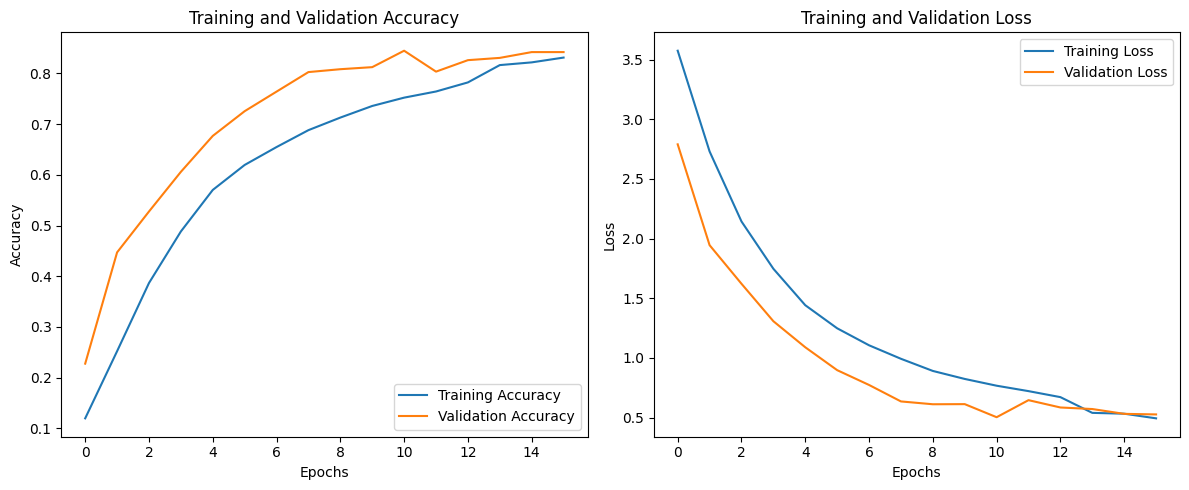

In [14]:
import matplotlib.pyplot as plt

# Extracting data from history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Create the plots
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

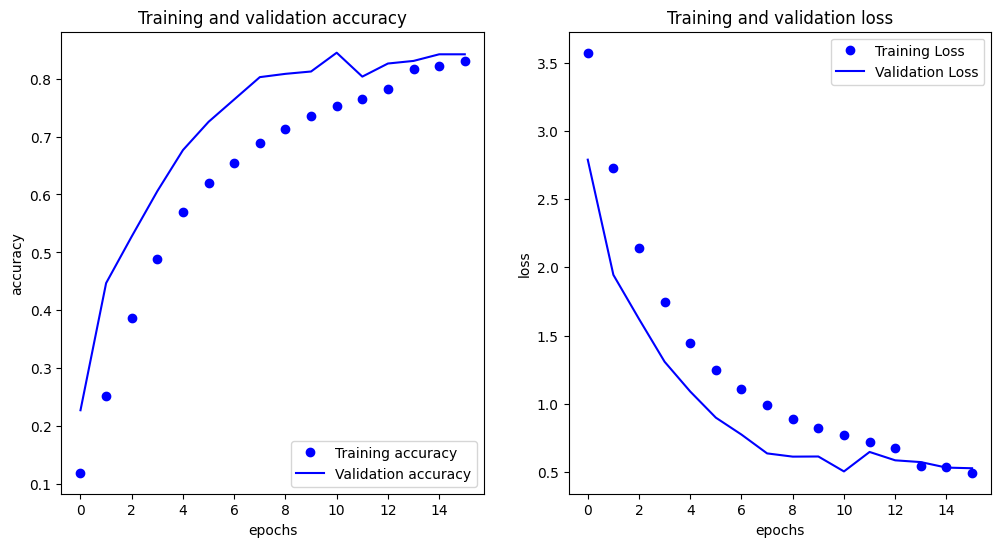

In [15]:
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
    ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
    ax[0].set_title('Training and validation accuracy')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].legend()

    ax[1].plot(epochs, loss, 'bo', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
    ax[1].set_title('Training and validation loss')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    ax[1].legend()

    plt.show()

plot_loss_acc(history)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Load model and get predictions
model = tf.keras.models.load_model("models/basiccnn/best_model.keras")

y_true = []
y_pred = []

for images, labels in test_dataset.take(500):
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [18]:

# ── 1. Classification Report ──────────────────────────────────────────
print(classification_report(y_true, y_pred, target_names=class_names))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.85      0.59      0.70        49
                                 Apple___Black_rot       0.79      1.00      0.88        52
                          Apple___Cedar_apple_rust       0.89      0.94      0.91        17
                                   Apple___healthy       0.82      0.78      0.80       114
                               Blueberry___healthy       0.93      0.92      0.92       113
          Cherry_(including_sour)___Powdery_mildew       0.90      0.93      0.91        68
                 Cherry_(including_sour)___healthy       0.81      0.90      0.85        58
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.93      0.83        44
                       Corn_(maize)___Common_rust_       0.93      1.00      0.96        96
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.79      0.

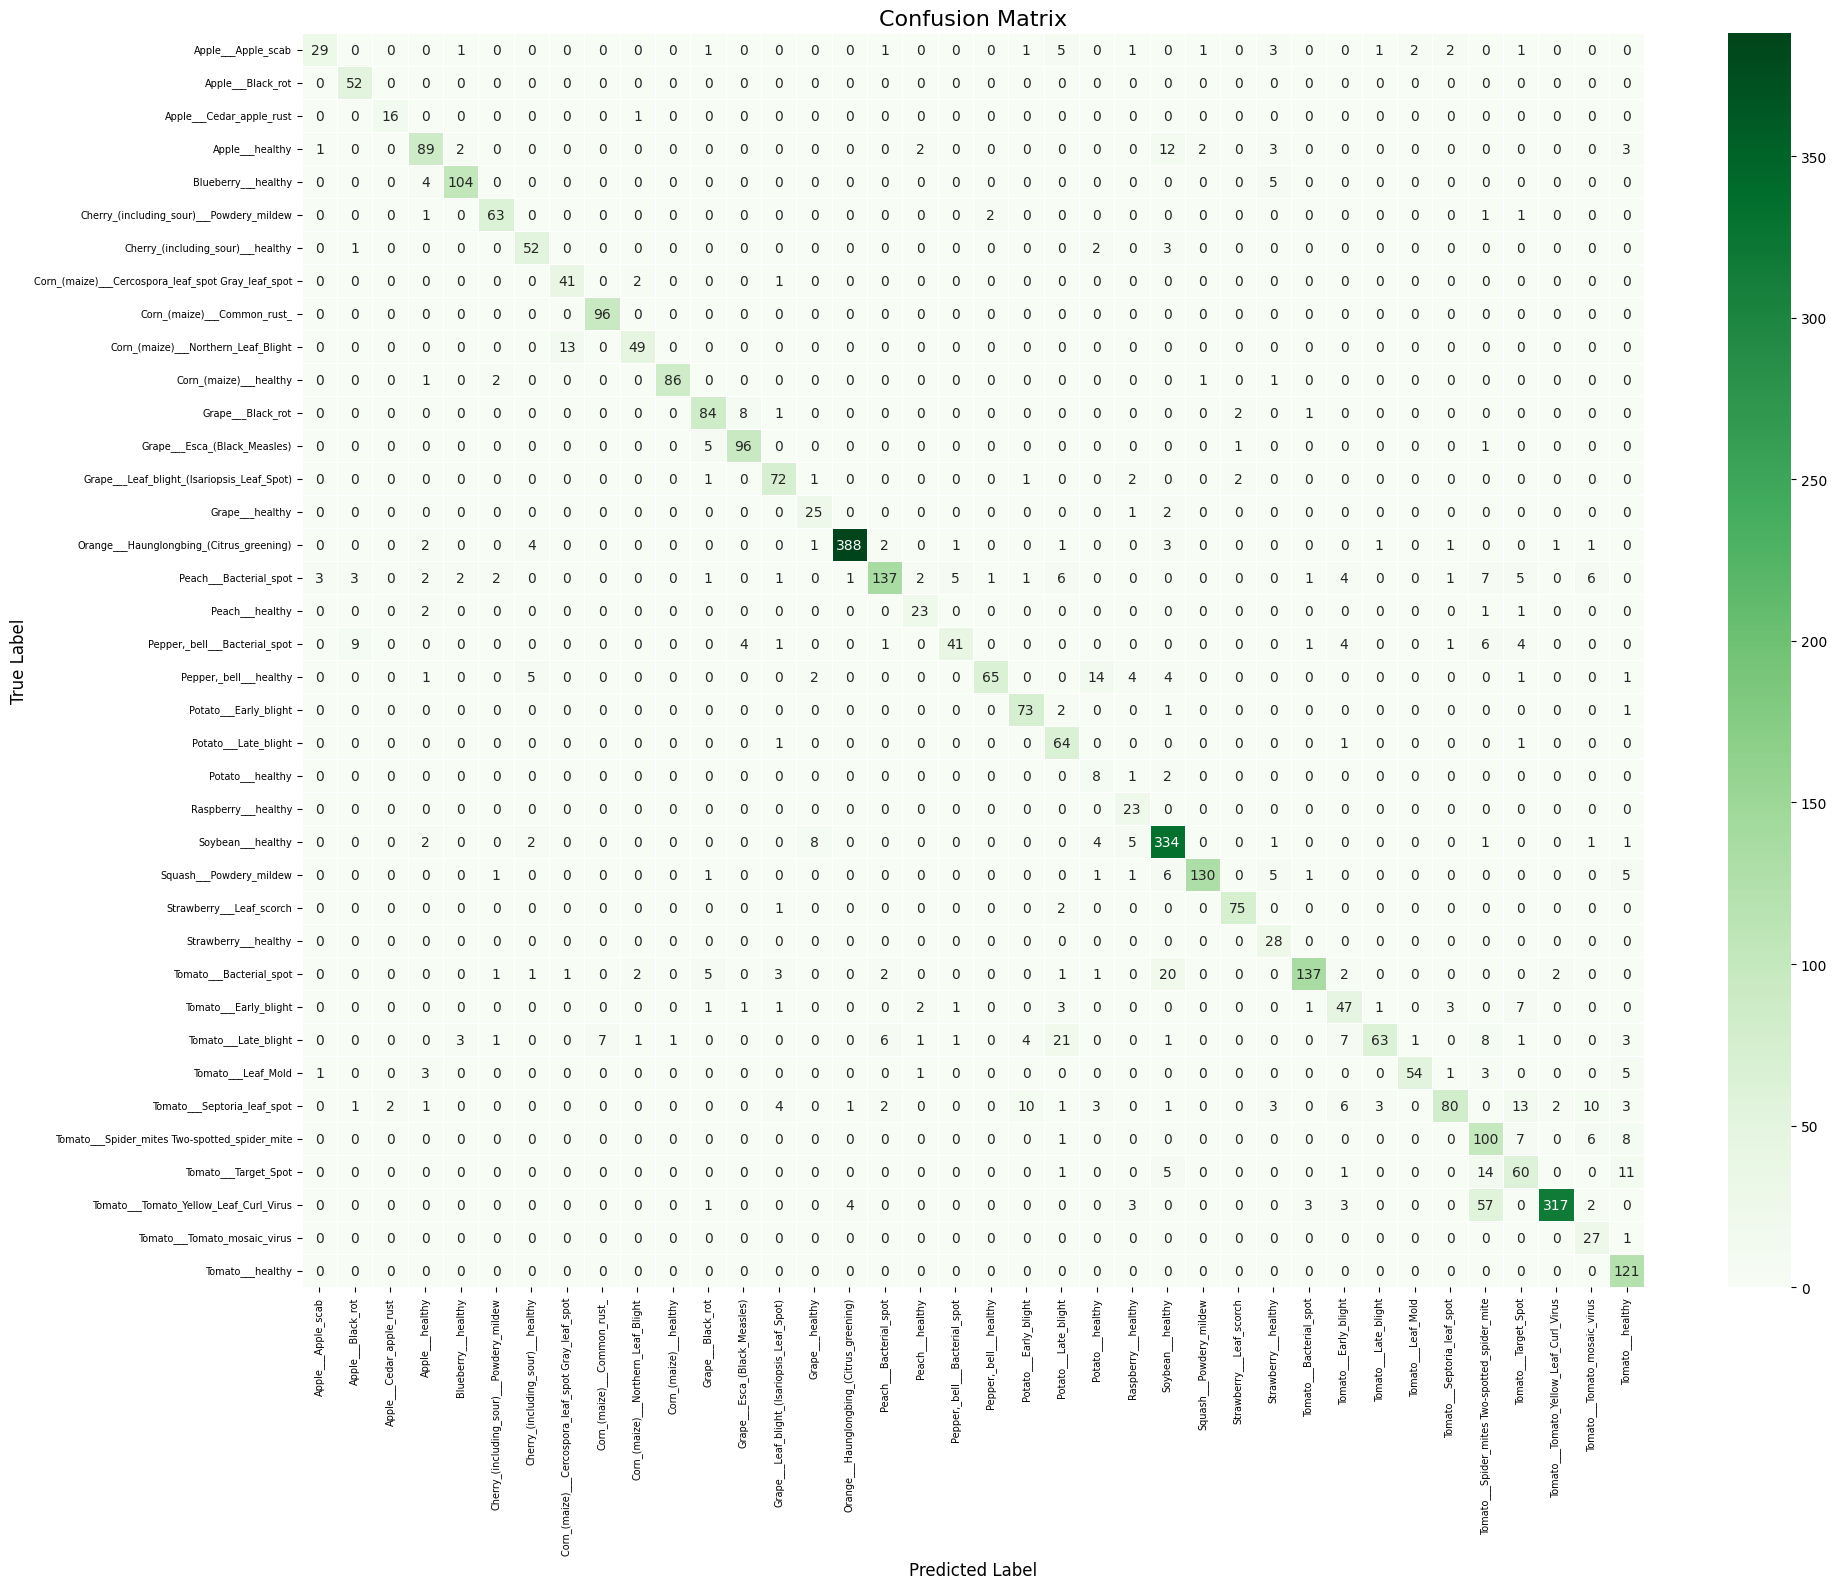

In [20]:

# ── 2. Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


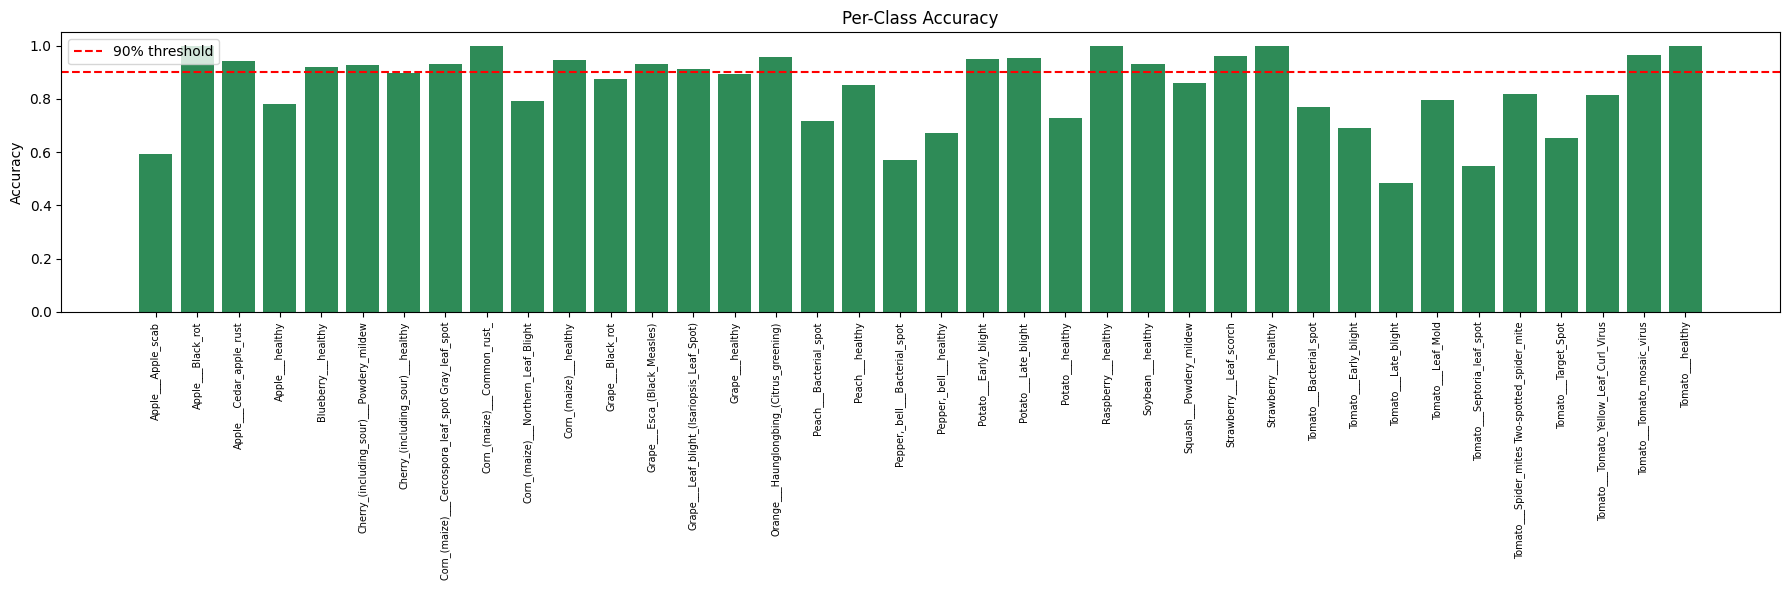

In [21]:

# ── 3. Per-Class Accuracy Bar Chart ──────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(18, 6))
bars = plt.bar(class_names, per_class_acc, color="seagreen")
plt.xticks(rotation=90, fontsize=7)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()


In [22]:

# ── 4. Top 5 Worst Performing Classes ────────────────────────────────
worst_idx = np.argsort(per_class_acc)[:5]
print("\nTop 5 Worst Performing Classes:")
for i in worst_idx:
    print(f"  {class_names[i]}: {per_class_acc[i]*100:.1f}%")


Top 5 Worst Performing Classes:
  Tomato___Late_blight: 48.5%
  Tomato___Septoria_leaf_spot: 54.8%
  Pepper,_bell___Bacterial_spot: 56.9%
  Apple___Apple_scab: 59.2%
  Tomato___Target_Spot: 65.2%
